## WEEK 2 - Employee Attrition Prediction using Machine Learning



**Objective**
Predict whether an employee is likely to leave the company using machine learning and identify the key factors influencing attrition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("data.csv")

In [3]:
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [4]:
df.shape


(1470, 35)

In [5]:
df.info()




<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

The target variable is imbalanced, with more employees staying than leaving.

In [7]:
attrition_rate = (237/1470)*100
print(attrition_rate)

16.122448979591837


Out of 1470 employees, only 237 left the company, resulting in an attrition rate of approximately 16.1%. Since the majority of employees stayed (83.9%), the dataset is imbalanced, which may affect model performance and should be handled during training.

In [8]:
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='object').columns

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

Numeric: 26
Categorical: 9


C:\Users\Vighnesh\AppData\Local\Temp\ipykernel_17860\3951927318.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


Task 1 inference :
* Dataset contains 1470 rows and 35 columns.
* Displayed the first 10 rows to understand the structure and features of the dataset.
* Identified Attrition as the target column to be predicted.
* The dataset contains 26 numerical columns and 9 categorical columns.
* No missing/null values were found in any column
* 16.12% of employees left the company , 83.88% of employees stayed , Observation: The dataset is imbalanced, as significantly more employees stayed than left the company.

In [9]:
df.isnull().sum()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [11]:
df.drop(
    ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'],
    axis=1,
    inplace=True
)

In [12]:
df.shape

(1470, 31)

Removed 4 unecessary columns 

In [13]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [14]:
df['Attrition'] = df['Attrition'].map({'Yes': 1,'No': 0})

In [15]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [16]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [17]:
x.shape
y.shape

(1470,)

In [18]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [19]:
cat_cols = x.select_dtypes(include='object').columns

print(cat_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')


C:\Users\Vighnesh\AppData\Local\Temp\ipykernel_17860\501647606.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include='object').columns


In [20]:
x = pd.get_dummies(x,columns=cat_cols,drop_first=True)

In [21]:
x.shape

(1470, 44)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [23]:
X_scaled.shape

(1470, 44)

### Task 2 - Inference

* Checked the dataset for missing values and found no missing data.
* Removed unwanted and irrelevant columns that do not contribute to prediction.
* Converted the target column (**Attrition**) into numerical format.
* Separated the dataset into input features (**X**) and target variable (**y**).
* Applied One-Hot Encoding to convert categorical features into numerical form.
* Scaled the feature values using StandardScaler.
* The dataset is now cleaned and ready for exploratory data analysis and model building.



In [24]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index') * 100

dept_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


Insights :
3.1 
* Sales department has the highest attrition rate (20.63%),Research & Development has the lowest attrition rate (13.84%).
* The count of employees differ in each dept , so raw count taking the verdict would be false; thus we took attrition rate .


In [25]:
role_att = pd.crosstab(
    df['JobRole'],df['Attrition'],normalize='index'
) * 100

role_att.sort_values(by=1, ascending=False)

Attrition,0,1
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000



3.2
* Sales Representatives have the highest attrition rate (39.76%),Laboratory Technicians and Human Resources employees also show high attrition.

In [26]:
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

In [27]:
wlb_attrition = pd.crosstab(
    df['WorkLifeBalance'],df['Attrition'],normalize='index') * 100

wlb_attrition

Attrition,0,1
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [28]:
df.groupby('Attrition')['YearsAtCompany'].mean()

Attrition
0    7.369019
1    5.130802
Name: YearsAtCompany, dtype: float64

Lets dig a bit deeper

In [29]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],bins=[0, 2, 5, 10, 40],labels=['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years'],include_lowest=True)

pd.crosstab(
    df['TenureGroup'],df['Attrition'],normalize='index') * 100

Attrition,0,1
TenureGroup,,
0-2 Years,70.175439,29.824561
3-5 Years,86.175115,13.824885
6-10 Years,87.723214,12.276786
10+ Years,91.869919,8.130081


3.3

* Yes. Employees who left earned an average monthly income of ₹4,787, while employees who stayed earned ₹6,833 on average.

3.4 
* Yes.
Employees with poor work-life balance (rating 1) have the highest attrition rate (31.25%). Attrition is lower among employees with better work-life balance ratings.

3.5

* Employees with 0–2 years of tenure have the highest attrition rate (29.82%),attrition decreases as tenure increases,employees with 10+ years at the company have the lowest attrition rate (8.13%).

* The Sales department has the highest attrition rate (20.63%), indicating that employee retention efforts should be prioritized in this department.
* Sales Representatives show the highest attrition rate (39.76%), suggesting that this role faces significant retention challenges compared to other job roles.
* Employees who left the company earned an average monthly income of ₹4,787, compared to ₹6,833 for employees who stayed, indicating that lower compensation may contribute to attrition.
* Employees with poor work-life balance (rating 1) have an attrition rate of 31.25%, which is significantly higher than employees with better work-life balance ratings.
* Employees with 0–2 years of tenure have the highest attrition rate (29.82%), while employees with more than 10 years of service have the lowest attrition rate (8.13%), showing that attrition is concentrated among newer employees.

## TASK 3 finished

In [30]:
from sklearn.model_selection import train_test_split

Xtr, Xtst, ytr, ytst = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
print(Xtr.shape)
print(Xtst.shape)
print(ytr.shape)
print(ytst.shape)

(1176, 44)
(294, 44)
(1176,)
(294,)


Data split

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(Xtr, ytr)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [33]:
lr.score(Xtr, ytr)

0.7789115646258503

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(Xtr, ytr)

rf.score(Xtr, ytr)

1.0

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(Xtr, ytr)

gb.score(Xtr, ytr)

0.9566326530612245

In [36]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Training Score': [0.778, 1.000, 0.950]
})

comparison

,Model,Training Score
0,Logistic Regression,0.778
1,Random Forest,1.000
2,Gradient Boosting,0.950


Trained all data and stored the scores in a table 

##  TASK 4 complete 


Task 5 has areas out of my expertise, I'll refer the internet and will be solving .

In [37]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

models = {
    "Logistic Regression": lr,
    "Gradient Boosting": gb,
    "Random Forest": rf
}

for name, model in models.items():

    y_pred = model.predict(Xtst)
    y_prob = model.predict_proba(Xtst)[:,1]

    print(f"\n{name}")
    print("="*50)

    print("Classification Report:")
    print(classification_report(ytst, y_pred))

    print("ROC-AUC Score:")
    print(roc_auc_score(ytst, y_prob))

    print("Confusion Matrix:")
    print(confusion_matrix(ytst, y_pred))


Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC-AUC Score:
0.798604530967353
Confusion Matrix:
[[191  56]
 [ 18  29]]

Gradient Boosting
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

ROC-AUC Score:
0.7943836678439142
Confusion Matrix:
[[240   7]
 [ 37  10]]

Random Forest
Classification Report:
              precision    recall  f1-score   support

           0      

In [38]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():

    y_pred = model.predict(Xtst)
    y_prob = model.predict_proba(Xtst)[:,1]

    results.append({
        "Model": name,
        "Precision": precision_score(ytst, y_pred),
        "Recall": recall_score(ytst, y_pred),
        "F1 Score": f1_score(ytst, y_pred),
        "ROC-AUC": roc_auc_score(ytst, y_prob)
    })

import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.341176  0.617021  0.439394  0.798605
1    Gradient Boosting   0.588235  0.212766  0.312500  0.794384
2        Random Forest   0.468750  0.319149  0.379747  0.771169


* Logistic Regression was selected as the best-performing model. Although Gradient Boosting achieved the highest overall accuracy (85%), Logistic Regression obtained the highest Recall (62%), F1-Score (44%), and ROC-AUC Score (0.799) for the attrition class. Since the primary objective is to correctly identify employees who are likely to leave the organization, Logistic Regression provides the best balance between detecting attrition cases and maintaining overall predictive performance.

In [39]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
34,JobRole_Laboratory Technician,0.797874,0.797874
43,OverTime_Yes,0.766412,0.766412
23,BusinessTravel_Travel_Frequently,0.719335,0.719335
7,JobLevel,0.659189,0.659189
16,TotalWorkingYears,-0.656931,0.656931
40,JobRole_Sales Representative,0.552515,0.552515
24,BusinessTravel_Travel_Rarely,0.511649,0.511649
27,EducationField_Life Sciences,-0.506505,0.506505
21,YearsSinceLastPromotion,0.500389,0.500389
26,Department_Sales,0.481690,0.481690


Feature importance was determined using the coefficients of the Logistic Regression model. It was found the main feature affecting was JobRole specifically as labtechnician 

In [40]:
top10 = feature_importance.head(10)

print(top10[['Feature','Coefficient']])

                             Feature  Coefficient
34     JobRole_Laboratory Technician     0.797874
43                      OverTime_Yes     0.766412
23  BusinessTravel_Travel_Frequently     0.719335
7                           JobLevel     0.659189
16                 TotalWorkingYears    -0.656931
40      JobRole_Sales Representative     0.552515
24      BusinessTravel_Travel_Rarely     0.511649
27      EducationField_Life Sciences    -0.506505
21           YearsSinceLastPromotion     0.500389
26                  Department_Sales     0.481690


The analysis indicates that employees working overtime, travelling frequently, and working in certain job roles are more likely to leave the organization. On the other hand, employees with higher total working experience tend to have lower attrition rates. These insights can help HR teams focus on retention strategies for high-risk employee groups.

##  TASK 5 COMPLETE

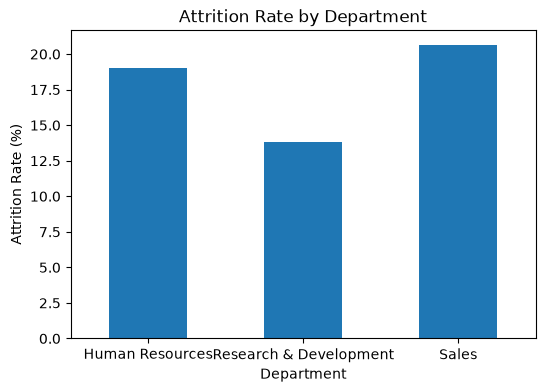

In [41]:
import matplotlib.pyplot as plt

dept_attrition = df.groupby("Department")["Attrition"].mean() * 100

plt.figure(figsize=(6,4))
dept_attrition.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

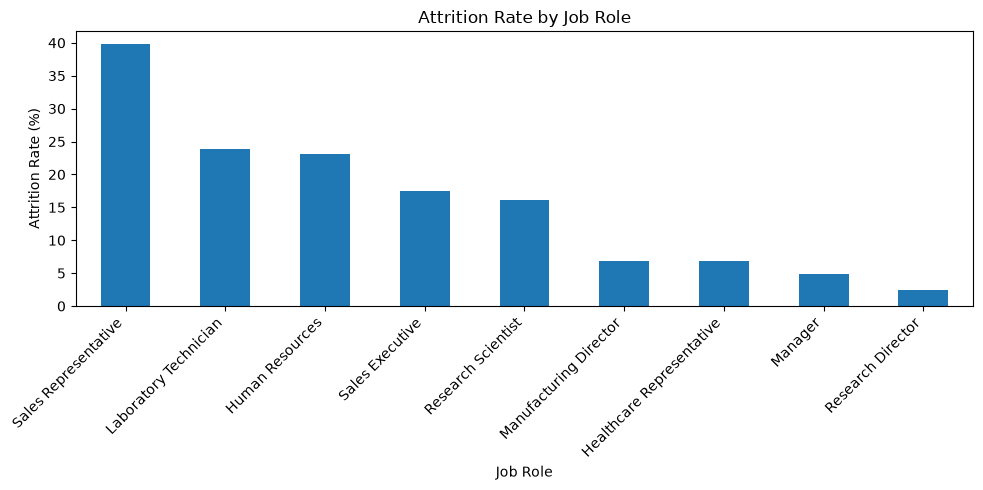

In [42]:
job_attrition = (
    df.groupby("JobRole")["Attrition"].mean().mul(100).sort_values(ascending=False))

plt.figure(figsize=(10,5))
job_attrition.plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Bar chart showing attrition rate by Department and Job Role

<Figure size 600x500 with 0 Axes>

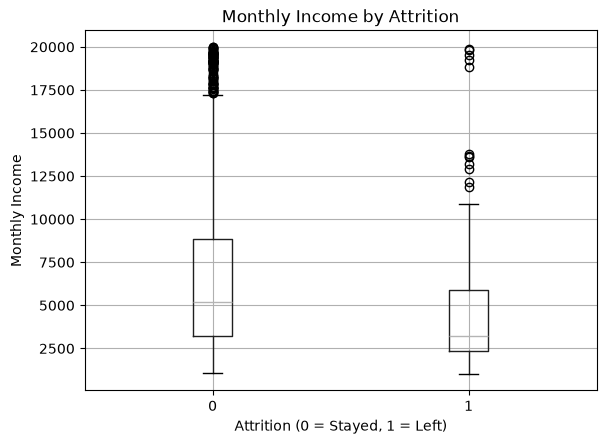

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

df.boxplot(column='MonthlyIncome', by='Attrition')

plt.title('Monthly Income by Attrition')
plt.suptitle('') 
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Monthly Income')

plt.show()

Box Plot comparing Monthly Income of employees who left vs stayed

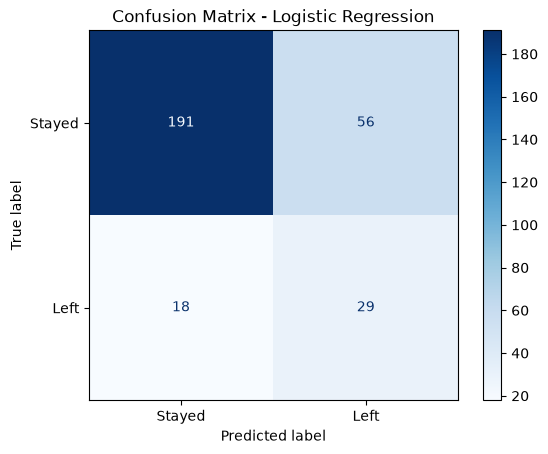

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = lr.predict(Xtst)

ConfusionMatrixDisplay.from_predictions(
    ytst,y_pred,cmap="Blues",display_labels=["Stayed", "Left"])

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Confusion Matrix Heatmap

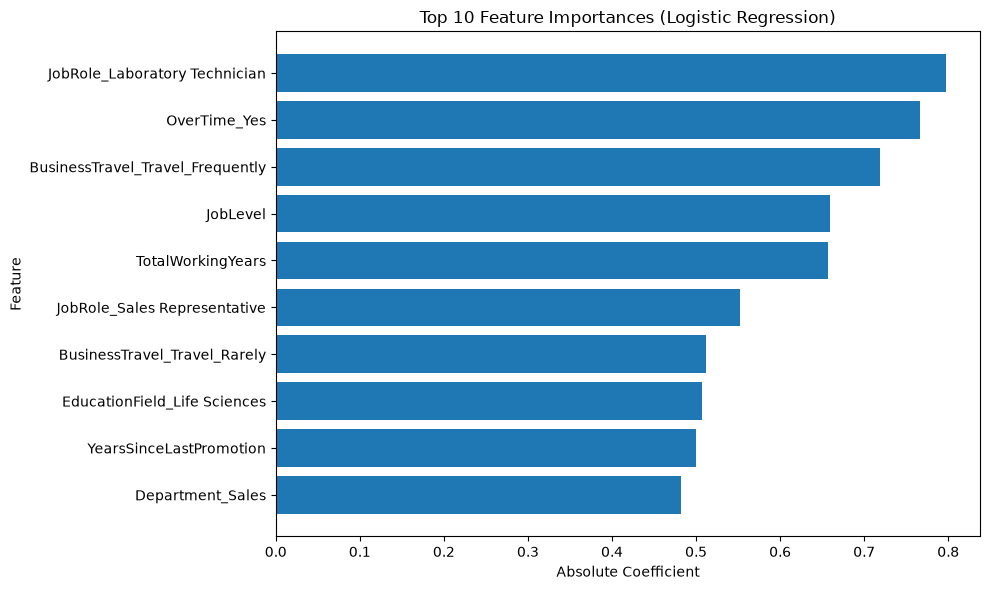

In [45]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Abs_Coefficient"])

plt.title("Top 10 Feature Importances (Logistic Regression)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()   

plt.tight_layout()
plt.show()

Horizontal Bar Chart of Top 10 Feature Importances.

In [46]:
from sklearn.metrics import roc_curve, auc

lr_prob = lr.predict_proba(Xtst)[:, 1]
gb_prob = gb.predict_proba(Xtst)[:, 1]
rf_prob = rf.predict_proba(Xtst)[:, 1]


lr_fpr, lr_tpr, _ = roc_curve(ytst, lr_prob)
gb_fpr, gb_tpr, _ = roc_curve(ytst, gb_prob)
rf_fpr, rf_tpr, _ = roc_curve(ytst, rf_prob)

lr_auc = auc(lr_fpr, lr_tpr)
gb_auc = auc(gb_fpr, gb_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

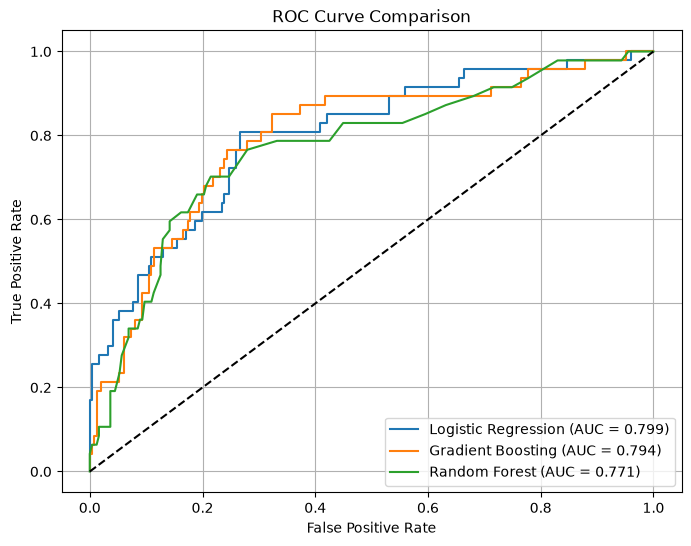

In [47]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

plt.plot(gb_fpr, gb_tpr,
         label=f'Gradient Boosting (AUC = {gb_auc:.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

# Random Guess line
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

Task 6 Insights :
* The Sales department has the highest attrition rate, while Research & Development has the lowest attrition rate.
* Sales Representatives have the highest attrition rate, whereas Research Directors have the lowest attrition rate.
* Employees who left the organization generally have a lower median monthly income than employees who stayed.
* The model correctly classified 191 employees who stayed and 29 employees who left, with comparatively fewer incorrect predictions.
* JobRole_Laboratory Technician, OverTime_Yes, and BusinessTravel_Travel Frequently are the top three most important features influencing employee attrition.
* Logistic Regression achieved the highest ROC-AUC score (0.799), followed closely by Gradient Boosting (0.794), while Random Forest (0.771) showed the lowest ROC-AUC score among the three models.

## TASK 7 

* The three strongest factors predicting employee attrition are:

    * JobRole_Laboratory Technician
    * OverTime_Yes
    * BusinessTravel_Travel Frequently

* HR should prioritize employees in the Sales department, especially Sales Representatives, as they have the highest attrition rate.

* No. Salary alone does not explain employee attrition. Factors such as overtime, job role, business travel frequency, and total working years have a stronger influence on whether an employee leaves the organization.

* According to me Reduce excessive overtime and promote a better work-life balance for employees and conduct regular retention meetings and career development programs for employees in high-risk job roles, especially Sales Representatives and Laboratory Technicians. 